# Bluexprice — Python EDA and Model Exploration

Status: In Development  
Data: deterministic public demo data  
Purpose: portfolio demonstration, not investment advice

## tl;dr

All input checks passed (0 failures). Estimated costs reduced the monthly demo result by an average of 1.163 percentage points. Random forest reached F1 0.990 versus 0.812 for the majority baseline. The high score reflects deterministic synthetic patterns and should not be treated as evidence of real-market predictability or profitability.

## Context & Methods

The analysis uses outputs generated by the public SQL workflow. Models use a chronological 70/30 holdout, and all predictive features come from earlier observations.

### Key assumptions

- Asset names and market prices are synthetic.
- Portfolio weights are illustrative and fixed.
- Fees and slippage are simplified estimates.
- ML scores test implementation and validation logic, not profitability.

## Data

### 1. Run and validate the analysis

In [1]:
from python_analysis.run_analysis import run_analysis
results = run_analysis()
results['quality_checks']

{'duplicate_daily_keys': 0,
 'missing_close_prices': 0,
 'non_positive_close_prices': 0,
 'missing_portfolio_months': 0}

### 2. Review the decision-ready summary

In [2]:
results['summary']

,metric,value,unit,interpretation
0,daily_demo_rows,720.000,rows,Public synthetic asset observations
1,quality_checks_failed,0.000,checks,Zero is required before analysis
2,average_monthly_cost_drag,1.163,percentage points,Demo difference between gross and net return sums
3,best_demo_model_f1,0.990,score,Random forest on deterministic synthetic data;...


## Results

### 3. Compare asset contribution and risk

In [3]:
results['asset_profile']

,asset_id,asset_group,average_weight_pct,average_monthly_contribution_pct,average_annualized_volatility_pct,positive_contribution_months,observed_months,contribution_rank
0,ASSET_A,Growth Equity,35.0,0.790000,16.265000,6,6,1
1,ASSET_B,Quality Equity,30.0,0.471667,19.775000,5,6,2
2,ASSET_C,Defensive Equity,20.0,0.291667,21.671667,5,6,3
3,ASSET_D,Diversifier,15.0,0.253333,22.560000,6,6,4


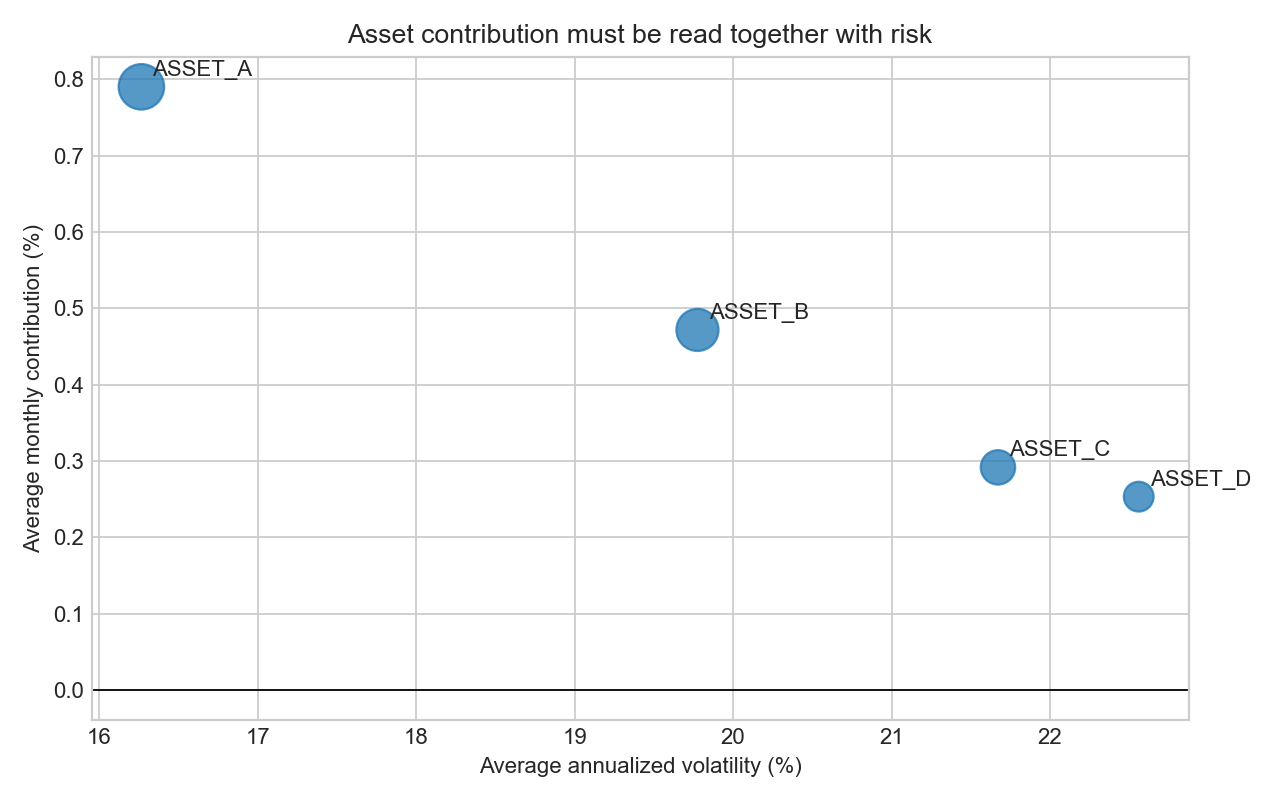

In [4]:
from IPython.display import Image, display
display(Image(filename='reports/python/asset_risk_contribution.png'))

### 4. Compare simple models with a baseline

In [5]:
results['model_results'].round(3)

,model,split_method,train_rows,test_rows,accuracy,balanced_accuracy,precision,recall,f1_score
0,Majority baseline,chronological 70/30 holdout,484,212,0.684,0.500,0.684,1.000,0.812
1,Logistic regression,chronological 70/30 holdout,484,212,0.972,0.967,0.979,0.979,0.979
2,Random forest,chronological 70/30 holdout,484,212,0.986,0.990,1.000,0.979,0.990


In [6]:
results['feature_importance'].round(3)

,feature,importance
2,price_vs_rolling_lag_1,0.489
1,return_mean_5,0.229
0,return_lag_1,0.228
3,volume_change_lag_1,0.053


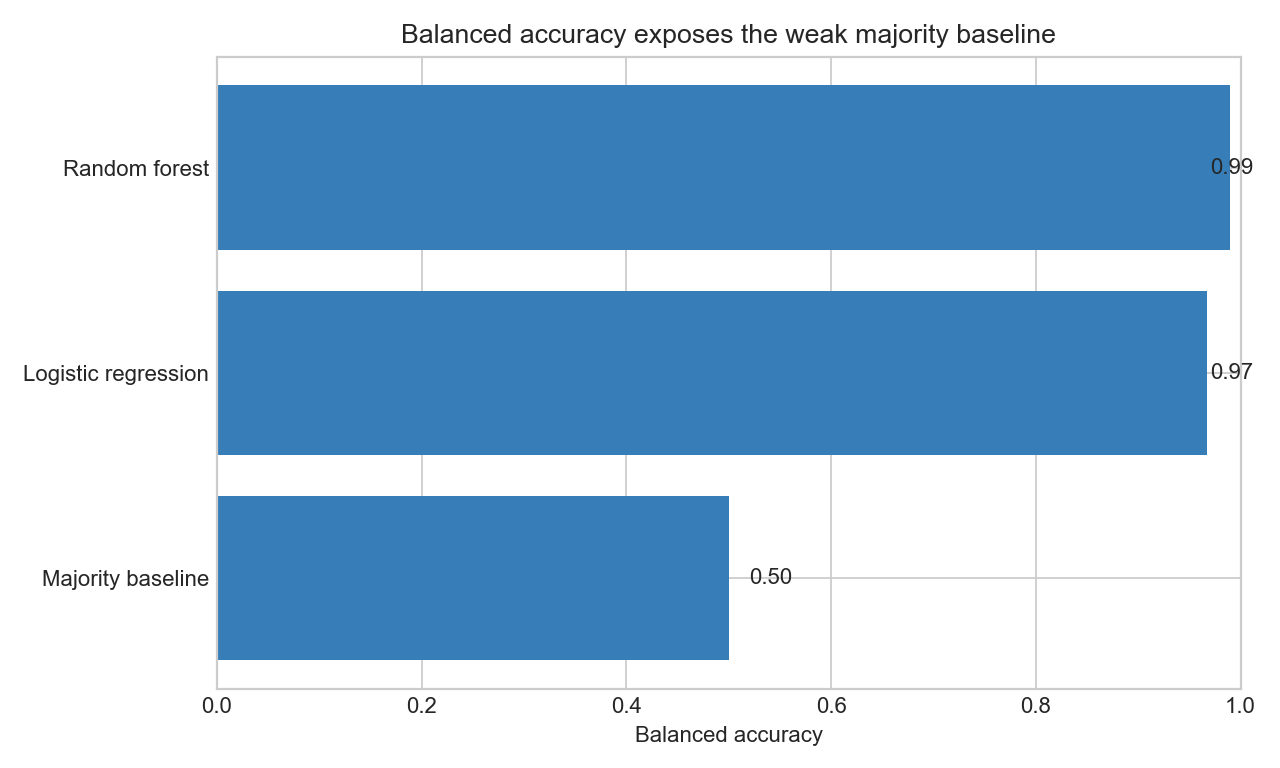

In [7]:
display(Image(filename='reports/python/model_balanced_accuracy.png'))

### 5. Review the effect of estimated execution costs

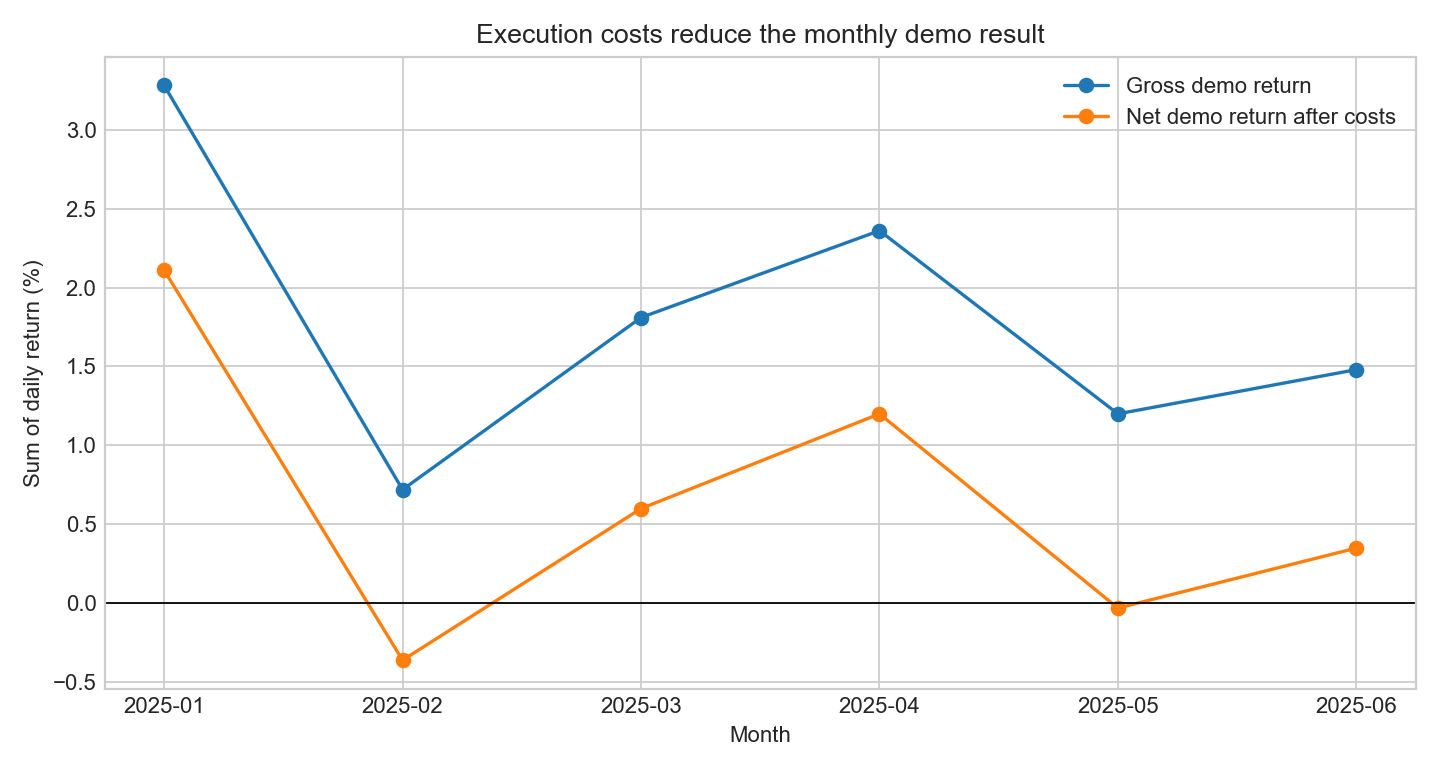

In [8]:
display(Image(filename='reports/python/monthly_gross_vs_net.png'))

## Takeaways

- Data-quality checks pass before the analysis is promoted.
- Estimated execution costs reduce the demo portfolio result, so gross performance should not be presented alone.
- Contribution and volatility should be assessed together.
- A model is useful only if it is compared with a simple baseline on later observations. The near-perfect demo score is a warning about synthetic-data simplicity, not a performance claim.
- The next portfolio step is to expose these sanitized summaries through Tableau Public.